In [1]:
import brainsss
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import fcluster
from scipy.cluster import hierarchy
from scipy.signal import butter, filtfilt, freqz
from scipy import signal
import matplotlib as mpl
from matplotlib.pyplot import cm
import random
from scipy.stats import sem, zscore
import time
import h5py
import ants
import nibabel as nib
import matplotlib
from scipy.ndimage import gaussian_filter1d
import pickle
from skimage import io
import glob
from itertools import combinations
import plotly.io as pio
pio.renderers.default = "notebook_connected"
import plotly.graph_objects as go
import matplotlib.colors as mcolors

In [2]:
fly_nums=[226,227,228,234,239,240,241,242,249,250]

In [3]:
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/'
behave_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/behave_all'
if not os.path.exists(behave_dir):
    os.mkdir(behave_dir)


In [4]:
%%time
fictrac_data={}
for num in fly_nums:
    fictrac_data[num]={}
    fly_num = f'fly_{num}'
    func_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/{fly_num}/'
    vision_path = os.path.join(func_path,'func_0', 'visual')
    ### Load Photodiode ###
    t, ft_triggers, pd1, pd2 = brainsss.load_photodiode(vision_path)
    stimulus_start_times = brainsss.extract_stim_times_from_pd(pd1, t)
    if stimulus_start_times.shape[0]<150:
        stimulus_start_times = brainsss.extract_stim_times_from_pd(pd2, t)

    # *100 puts in units of 10ms, which will match fictrac
    st_10ms = [int(stimulus_start_times[i]*100) for i in range(len(stimulus_start_times))]

    # get 1ms version to match neural timestamps
    st_ms= [i*10 for i in st_10ms]
    starts_loom = st_10ms
    starts_loom_ms = [n*10 for n in starts_loom]
    fictrac_path = os.path.join(func_path, 'func_0', 'fictrac')
    fictrac_raw = brainsss.load_fictrac(fictrac_path)

    fps = 100
    resolution = 10 #desired resolution in ms
    expt_len = fictrac_raw.shape[0]/fps*1000
    behaviors = ['dRotLabY', 'dRotLabZ', 'dRotLabX']
    fictrac_data[num]['behave'] = brainsss.smooth_and_interp_fictrac(fictrac_raw, fps, resolution, expt_len, behaviors[0])
    fictrac_data[num]['ts'] = np.arange(0,expt_len,resolution)

loading photodiode data... done
loading photodiode data... done
loading photodiode data... done
loading photodiode data... done
loading photodiode data... done
loading photodiode data... done
loading photodiode data... done
loading photodiode data... done
loading photodiode data... done
loading photodiode data... done
CPU times: user 45.8 s, sys: 4.53 s, total: 50.3 s
Wall time: 1min 26s


(180000,)

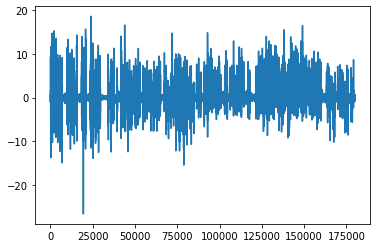

In [5]:
plt.plot(fictrac_data[250]['behave'])
fictrac_data[226]['behave'].shape

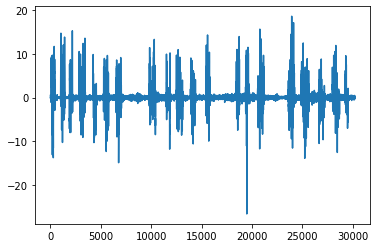

In [6]:
plt.plot(fictrac_data[250]['behave'][:starts_loom[0]])

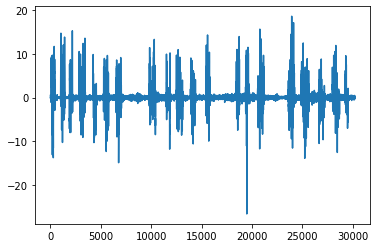

In [56]:
plt.plot(fictrac_data[250]['behave'][:starts_loom[0]])

In [63]:
# 100==1sec
val_pos=0.1 #10 #
val_neg=-0.1 #-10 #
great_pos=1 #100 #
great_neg=-1 #-100 #
behave_dict={}
start=200
end=start+300
for fly in fictrac_data:
    fly=str(fly)
    behave_dict[fly]={'inc':[],'dec':[],'flat':[]}
    first5=np.asarray(fictrac_data[int(fly)]['behave'][:starts_loom[0]])
    for i in range(len(first5)):
        if i+end<len(first5):
            loom_start=i+start
            pre=np.mean(first5[(loom_start-50):loom_start])
            post=np.mean(first5[(loom_start+50):(loom_start+100)])
            if pre>val_neg and pre<val_pos and post>val_neg and post<val_pos:
#                 print(first5[i:(i+50)].max(),first5[i:(i+50)].min(),pre)
                if behave_dict[fly]['flat']==[] or behave_dict[fly]['flat'][-1]>i:
                    behave_dict[fly]['flat'].append(i)
                else:
                    if behave_dict[fly]['flat'][-1]+end<=i:
                        behave_dict[fly]['flat'].append(i)
            elif post>np.abs(pre*2):
    #         elif pre>great_neg and pre <val_pos and post>great_pos and post>np.abs(pre*2):
                if behave_dict[fly]['inc']==[] or behave_dict[fly]['inc'][-1]>i:
                    behave_dict[fly]['inc'].append(i)
                else:
                    if behave_dict[fly]['inc'][-1]+end<=i:
                        behave_dict[fly]['inc'].append(i)
            elif post<pre/2:
    #         elif pre>great_pos and post<val_pos and post>great_neg and post<pre/2:
                if behave_dict[fly]['dec']==[] or behave_dict[fly]['dec'][-1]>i:
                    behave_dict[fly]['dec'].append(i)
                else:
                    if behave_dict[fly]['dec'][-1]+end<=i:
                        behave_dict[fly]['dec'].append(i)
    behave_dict[fly]['inc']=np.array(behave_dict[fly]['inc'])
    behave_dict[fly]['dec']=np.array(behave_dict[fly]['dec'])
    behave_dict[fly]['flat']=np.array(behave_dict[fly]['flat'])

In [64]:
avg_be={'inc':[],'dec':[],'flat':[]}
for fly in behave_dict:
    for b in behave_dict[fly]:
#         print(b)
        arr=behave_dict[fly][b]
#         print(np.shape(arr))
        for tp in arr:
            avg_be[b].append(fictrac_data[int(fly)]['behave'][tp:(tp+end)])
avg_be['inc']=np.array(avg_be['inc'])
print(f'Inc: {avg_be["inc"].shape}')
avg_be['dec']=np.array(avg_be['dec'])
print(f'Dec: {avg_be["dec"].shape}')
avg_be['flat']=np.array(avg_be['flat'])
print(f'Flat: {avg_be["flat"].shape}')

Inc: (485, 500)
Dec: (523, 500)
Flat: (425, 500)


In [65]:
behavior_colors={
    'inc': '#FC00B9',
    'dec': '#17D4DE',
    'flat': '#000000',
    'non': '#F5F5F5',
    'total': '#F5F5F5',
    'other': '#F5F5F5'
}

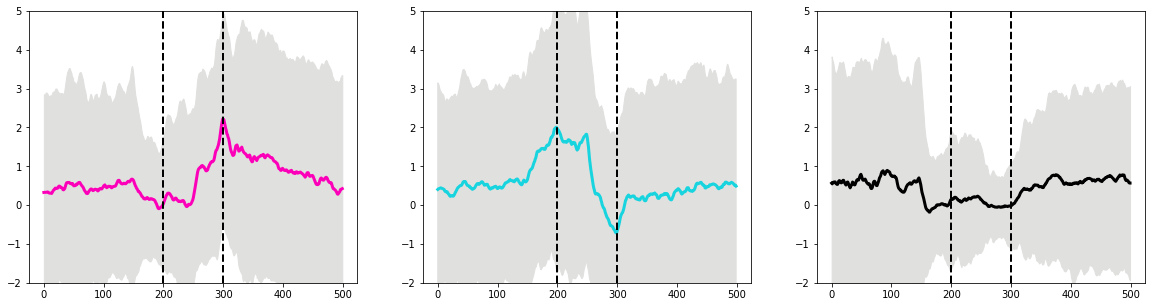

In [66]:
fig,axs=plt.subplots(1,len(list(avg_be.keys())),figsize=(20,5))
for i,be in enumerate(avg_be):
    mean_trace=np.mean(avg_be[be], axis=0)
    std_trace=np.std(avg_be[be], axis=0)
    axs[i].plot(mean_trace, color=behavior_colors[be],lw=3)
    axs[i].fill_between(np.arange(len(mean_trace)),mean_trace-std_trace, mean_trace+std_trace, color='#e0e0df')
    axs[i].axvline((start), linewidth=2, linestyle='--', color='k')
    axs[i].axvline((start+100), linewidth=2, linestyle='--', color='k')
    axs[i].set_ylim(-2, 5);


In [67]:
print(behave_dict.keys())
print(behave_dict['226'].keys())
print(behave_dict['226']['inc'])

dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])
dict_keys(['inc', 'dec', 'flat'])
[  246   788  1288  1988  2488  2988  3488  4245  4745  5245  5815  6315
  6815  7533  8225  8725  9324 10201 10812 11372 11872 12419 12919 13430
 13930 14443 15036 15734 16379 17269 17769 18498 18998 19601 20251 20751
 21251 21754 22289 23077 23657 24215 24812 25416 25968 26491 27067 27651
 28481 29263]


In [68]:
for fly in behave_dict:
    for be in behave_dict[fly]:
        behave_dict[fly][be]=behave_dict[fly][be]*10

In [72]:
# new_event_name='first_5'
# event_list=behave_dict

# later_path = os.path.join(later_dir, f'{new_event_name}_event_times_split_dic.pkl')

# with open(later_path, 'wb') as file:
#     pickle.dump(event_list, file)

In [70]:
fly_name='226'
be='inc'
starts_loom_ms = behave_dict[fly_name][be]
# starts_loom_ms=np.sort(starts_loom_ms)

bin_start = -2000; bin_end = 3000; bin_size = 100 #ms

bins_array=[]
for loom in starts_loom_ms:
#     print(loom)
    start=loom+bin_start
    end=loom+bin_end-bin_size   # why did i subtract out bin size??? 
#     edges=[start,end]
    bins_array.append(start)
    bins_array.append(end)
# bins_test=np.vstack(bins_test)
bins_array=np.array(bins_array)
bins_shape=np.shape(bins_array)

In [71]:
bins_array

array([   460,   5360,   5880,  10780,  10880,  15780,  17880,  22780,
        22880,  27780,  27880,  32780,  32880,  37780,  40450,  45350,
        45450,  50350,  50450,  55350,  56150,  61050,  61150,  66050,
        66150,  71050,  73330,  78230,  80250,  85150,  85250,  90150,
        91240,  96140, 100010, 104910, 106120, 111020, 111720, 116620,
       116720, 121620, 122190, 127090, 127190, 132090, 132300, 137200,
       137300, 142200, 142430, 147330, 148360, 153260, 155340, 160240,
       161790, 166690, 170690, 175590, 175690, 180590, 182980, 187880,
       187980, 192880, 194010, 198910, 200510, 205410, 205510, 210410,
       210510, 215410, 215540, 220440, 220890, 225790, 228770, 233670,
       234570, 239470, 240150, 245050, 246120, 251020, 252160, 257060,
       257680, 262580, 262910, 267810, 268670, 273570, 274510, 279410,
       282810, 287710, 290630, 295530])